### 1. Exploración de Datos:

**a. Cargar los datos:**
Para cargar los datos, generalmente utilizamos la biblioteca `pandas` en Python. Aquí hay un ejemplo de cómo cargar los datos de entrenamiento y prueba:

```python
import pandas as pd

# Cargar los datos
train_data_path = '/kaggle/input/titanic/train.csv'
train_data = pd.read_csv(train_data_path)

test_data_path = '/kaggle/input/titanic/test.csv'
test_data = pd.read_csv(test_data_path)

# Ver las primeras filas del conjunto de entrenamiento
print(train_data.head())
```

In [1]:
import pandas as pd

# Cargar los datos
train_data_path = '/kaggle/input/titanic/train.csv'
train_data = pd.read_csv(train_data_path)

test_data_path = '/kaggle/input/titanic/test.csv'
test_data = pd.read_csv(test_data_path)

# Ver las primeras filas del conjunto de entrenamiento
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



**b. Análisis exploratorio:**
Una vez que hayas cargado los datos, es útil obtener una visión general de ellos:

```python
# Información general sobre el conjunto de entrenamiento
print(train_data.info())

# Estadísticas descriptivas
print(train_data.describe())
```

In [2]:
# Información general sobre el conjunto de entrenamiento
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# Estadísticas descriptivas
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Esto te dará una idea de las características disponibles, la cantidad de valores faltantes y algunas estadísticas básicas para las características numéricas.

**c. Visualización de datos:**
La visualización es una herramienta poderosa para entender los datos. Puedes usar la biblioteca `matplotlib` o `seaborn` para visualizar la distribución de las características y la relación entre ellas. Por ejemplo, para visualizar la tasa de supervivencia según el género:

```python
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', hue='Survived', data=train_data)
plt.title('Tasa de supervivencia según el género')
plt.show()
```

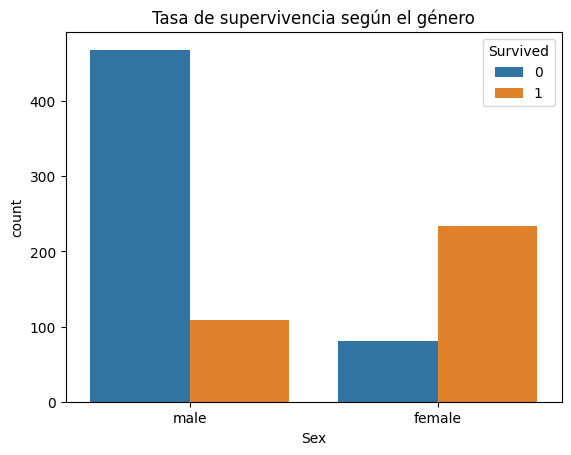

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', hue='Survived', data=train_data)
plt.title('Tasa de supervivencia según el género')
plt.show()


Estos son solo algunos pasos básicos para comenzar con la exploración de datos. A medida que profundices en el análisis, podrías descubrir patrones interesantes o relaciones que podrían ser útiles para la construcción del modelo.


¡Genial! Prosigamos con el **Preprocesamiento de Datos**.

### 2. Preprocesamiento de Datos:

**a. Manejo de valores faltantes:**
Es común encontrar valores faltantes en conjuntos de datos. Es esencial manejarlos adecuadamente para evitar errores en el modelo.

```python
# Verificar valores faltantes
print(train_data.isnull().sum())

# Una estrategia común es rellenar los valores faltantes de 'Age' con la mediana
train_data['Age'].fillna(train_data['Age'].median(), inplace=True)

# Para 'Embarked', podemos rellenar con el valor más común
most_common_embarked = train_data['Embarked'].mode()[0]
train_data['Embarked'].fillna(most_common_embarked, inplace=True)
```

In [5]:
# Verificar valores faltantes
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Una estrategia común es rellenar los valores faltantes de 'Age' con la mediana
train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
train_data["Age"].isnull().sum()

/tmp/ipykernel_18/1783610337.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Age'].fillna(train_data['Age'].median(), inplace=True)


0

In [7]:
# Para 'Embarked', podemos rellenar con el valor más común
most_common_embarked = train_data['Embarked'].mode()[0]
train_data['Embarked'].fillna(most_common_embarked, inplace=True)
train_data["Embarked"].isnull().sum()

/tmp/ipykernel_18/1090745005.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Embarked'].fillna(most_common_embarked, inplace=True)


0

**b. Codificación de variables categóricas:**
Las máquinas entienden números, no texto. Por lo tanto, es necesario convertir las variables categóricas en formatos numéricos.

```python
# Convertir género a formato numérico: 0 para femenino y 1 para masculino
train_data['Sex'] = train_data['Sex'].map({'female': 0, 'male': 1}).astype(int)

# Codificar 'Embarked' usando codificación one-hot
embarked_dummies = pd.get_dummies(train_data['Embarked'], prefix='Embarked')
train_data = pd.concat([train_data, embarked_dummies], axis=1)
train_data.drop('Embarked', axis=1, inplace=True)
```

In [8]:
# Convertir género a formato numérico: 0 para femenino y 1 para masculino
train_data['Sex'] = train_data['Sex'].map({'female': 0, 'male': 1}).astype(int)
train_data['Sex']

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex, Length: 891, dtype: int64

In [9]:
# Codificar 'Embarked' usando codificación one-hot
embarked_dummies = pd.get_dummies(train_data['Embarked'], prefix='Embarked')
train_data = pd.concat([train_data, embarked_dummies], axis=1)
train_data.drop('Embarked', axis=1, inplace=True)
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')


**c. Creación de nuevas características:**
A veces, combinar o derivar nuevas características puede mejorar el rendimiento del modelo.

```python
# Crear una nueva característica 'FamilySize' que combina 'SibSp' y 'Parch'
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
```

In [10]:
# Crear una nueva característica 'FamilySize' que combina 'SibSp' y 'Parch'
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
train_data['FamilySize']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: FamilySize, Length: 891, dtype: int64


**d. Normalización o escala de características:**
Algunos modelos funcionan mejor cuando las características tienen una escala similar.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_data[['Age', 'Fare']] = scaler.fit_transform(train_data[['Age', 'Fare']])
```

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_data[['Age', 'Fare']])

StandardScaler()

In [12]:
train_data[['Age', 'Fare']] = scaler.transform(train_data[['Age', 'Fare']])

In [13]:
train_data[['Age', 'Fare']].describe()

,Age,Fare
count,8.910000e+02,8.910000e+02
mean,2.272780e-16,3.987333e-18
std,1.000562e+00,1.000562e+00
min,-2.224156e+00,-6.484217e-01
25%,-5.657365e-01,-4.891482e-01
50%,-1.046374e-01,-3.573909e-01
75%,4.333115e-01,-2.424635e-02
max,3.891554e+00,9.667167e+00



Estos son solo algunos pasos básicos para el preprocesamiento de datos. Dependiendo de la naturaleza de los datos y el modelo que elijas, es posible que necesites realizar más transformaciones.


### 3. Construcción del Modelo:

**a. Dividir el conjunto de entrenamiento:**
Antes de entrenar el modelo, es una buena práctica dividir el conjunto de entrenamiento en subconjuntos de entrenamiento y validación. Esto nos permite evaluar el rendimiento del modelo antes de hacer predicciones en el conjunto de prueba.

```python
from sklearn.model_selection import train_test_split

# Definir las características y la variable objetivo
X = train_data.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = train_data['Survived']

# Dividir los datos
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
```

In [14]:
from sklearn.model_selection import train_test_split

# Definir las características y la variable objetivo
X = train_data.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = train_data['Survived']

# Dividir los datos
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


**b. Seleccionar y entrenar un modelo inicial:**
Como punto de partida, podemos usar la Regresión Logística, que es un modelo simple pero efectivo para problemas de clasificación binaria. Comenzaremos desarrollando un modelos lineal y ajustando los resultados en el intervalo adecuado. 

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Inicializar y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de validación
y_pred = model.predict(X_val)

# Evaluar el rendimiento
print(mean_absolute_error(y_val, y_pred))
print(mean_squared_error(y_val, y_pred))
print(r2_score(y_val, y_pred))

0.2851455248860693
0.13507401231462193
0.4429978856405661



```python
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Inicializar y entrenar el modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de validación
y_pred = model.predict(X_val)

# Evaluar el rendimiento
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
```

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Inicializar y entrenar el modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de validación
y_pred = model.predict(X_val)

# Evaluar el rendimiento
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8101



**c. Evaluar el rendimiento del modelo:**
Es esencial evaluar cómo se desempeña el modelo en datos no vistos. Además de la precisión, hay otras métricas que pueden ser relevantes, como el recall, la precisión y el AUC-ROC.

```python
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))
```

La **matriz de confusión** es una herramienta para evaluar el desempeño de un modelo de clasificación, comparando las predicciones del modelo con las etiquetas reales. Es una tabla que organiza los resultados en cuatro categorías principales:

### **Estructura de la Matriz de Confusión (Para un problema binario)**

|                 | **Clase Predicha: Positiva** | **Clase Predicha: Negativa** |
|-----------------|------------------------------|------------------------------|
| **Clase Real: Positiva** | **True Positives (TP)**: Predicciones correctas como positivas.  | **False Negatives (FN)**: Predicciones incorrectas como negativas. |
| **Clase Real: Negativa** | **False Positives (FP)**: Predicciones incorrectas como positivas. | **True Negatives (TN)**: Predicciones correctas como negativas.    |

### **Definiciones de los Términos**
1. **True Positives (TP)**: 
   - Número de instancias correctamente clasificadas como positivas.
   - Ejemplo: El modelo detecta correctamente que alguien tiene una enfermedad.

2. **False Positives (FP)**: 
   - Número de instancias negativas clasificadas incorrectamente como positivas.
   - Ejemplo: El modelo predice que alguien tiene una enfermedad cuando no es así (falso alarma).

3. **True Negatives (TN)**: 
   - Número de instancias correctamente clasificadas como negativas.
   - Ejemplo: El modelo detecta correctamente que alguien no tiene la enfermedad.

4. **False Negatives (FN)**: 
   - Número de instancias positivas clasificadas incorrectamente como negativas.
   - Ejemplo: El modelo predice que alguien no tiene una enfermedad cuando en realidad sí la tiene.

---

### **Métricas Derivadas de la Matriz de Confusión**
A partir de la matriz de confusión, se pueden calcular varias métricas clave:

1. **Precisión (Precision)**:
   \[
   \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
   \]
   Proporción de positivos predichos que son correctos.

2. **Recall (Sensibilidad o TPR)**:
   \[
   \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
   \]
   Proporción de positivos reales que son correctamente clasificados.

3. **Exactitud (Accuracy)**:
   \[
   \text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}
   \]
   Proporción de predicciones correctas (positivas y negativas) sobre el total.

4. **Tasa de Falsos Positivos (FPR)**:
   \[
   \text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}
   \]
   Proporción de negativos reales que fueron mal clasificados como positivos.

5. **F1-Score**:
   \[
   \text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
   \]
   Media armónica entre precisión y recall.

---

### **Ejemplo de Matriz de Confusión**
Supongamos un problema de detección de spam donde tenemos 100 correos. Los resultados se dividen así:

|                 | **Predicho: Spam** | **Predicho: No Spam** |
|-----------------|--------------------|-----------------------|
| **Real: Spam**  | **TP = 40**       | **FN = 10**          |
| **Real: No Spam** | **FP = 5**       | **TN = 45**          |

- **Precisión**: $40 / (40 + 5) = 0.89$ (89% de los correos clasificados como spam son realmente spam).
- **Recall**: $40 / (40 + 10) = 0.80$ (80% de los correos spam fueron detectados).
- **Exactitud**: $(40 + 45) / 100 = 0.85$ (85% de las predicciones son correctas). 

La matriz de confusión proporciona una visión detallada de los errores del modelo y es fundamental para seleccionar métricas según las prioridades del problema (minimizar falsos positivos, falsos negativos, etc.).

In [17]:
from sklearn.metrics import confusion_matrix
# Calcular matriz de confusión
cm = confusion_matrix(y_val, y_pred)
print(cm)

[[90 15]
 [19 55]]


El `classification_report` de `sklearn.metrics` proporciona las principales métricas de clasificación para evaluar el rendimiento de un clasificador. Estas métricas incluyen:

1. **Precision (Precisión):** Esta métrica nos dice cuántos de los elementos identificados como positivos fueron realmente positivos. Es el cociente entre los verdaderos positivos y la suma de los verdaderos positivos y falsos positivos.
   
   $ \text{Precisión} = \frac{\text{Verdaderos Positivos}}{\text{Verdaderos Positivos} + \text{Falsos Positivos}} $

2. **Recall (Sensibilidad o Tasa Verdadera Positiva):** Esta métrica nos dice cuántos de los elementos que realmente eran positivos fueron identificados como tales. Es el cociente entre los verdaderos positivos y la suma de los verdaderos positivos y falsos negativos.
   
   $\text{Recall} = \frac{\text{Verdaderos Positivos}}{\text{Verdaderos Positivos} + \text{Falsos Negativos}}$

3. **F1-score (Puntaje F1):** Es una métrica que combina la precisión y el recall en una única cifra. Es útil cuando se quiere tener un balance entre la precisión y el recall. El F1-score es la media armónica de la precisión y el recall.
   
    $ \text{F1-score} = 2 \times \frac{\text{Precisión} \times \text{Recall}}{\text{Precisión} + \text{Recall}} $

4. **Support (Soporte):** Indica la cantidad de observaciones reales para cada clase en el conjunto de datos de prueba.

El reporte también proporciona estas métricas para cada clase individualmente y promedios (macro, ponderado) para problemas de clasificación multiclase.

Un ejemplo de cómo se vería este reporte es:

```
              precision    recall  f1-score   support

      Clase1       0.89      0.85      0.87       100
      Clase2       0.80      0.84      0.82        80

   micro avg       0.85      0.85      0.85       180
   macro avg       0.84      0.85      0.84       180
weighted avg       0.85      0.85      0.85       180
```

Donde:

- **micro avg**: Calcula las métricas globalmente contando el total de verdaderos positivos, falsos negativos y falsos positivos.
- **macro avg**: Calcula las métricas para cada etiqueta y encuentra su media no ponderada (sin tener en cuenta el soporte).
- **weighted avg**: Calcula las métricas para cada etiqueta y encuentra su media ponderada por soporte.

Este reporte te permite obtener rápidamente una visión general del rendimiento de tu clasificador, y entender mejor cómo se comporta en diferentes clases y en general.

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179




Estos pasos te proporcionan un modelo inicial y una evaluación básica de su rendimiento. A partir de aquí, puedes experimentar con diferentes modelos, ajustar hiperparámetros y realizar ingeniería de características adicional para mejorar el rendimiento.

La métrica **ROC AUC** (Receiver Operating Characteristic - Area Under Curve) es una medida comúnmente utilizada para evaluar el desempeño de un modelo de clasificación, especialmente en problemas de clasificación binaria. Combina dos aspectos clave:

1. **Curva ROC**: Representa gráficamente la relación entre la **tasa de verdaderos positivos** (True Positive Rate o Sensitivity) y la **tasa de falsos positivos** (False Positive Rate) a diferentes umbrales de decisión. Esto permite analizar cómo varía la capacidad del modelo para distinguir entre las clases positivas y negativas según se ajusta el umbral.

2. **AUC (Area Under the Curve)**: Es el área bajo la curva ROC, que cuantifica la habilidad del modelo para clasificar correctamente. Su valor está entre 0 y 1:
   - Un AUC de **1** indica un modelo perfecto.
   - Un AUC de **0.5** implica que el modelo no es mejor que adivinar al azar.
   - Un AUC cercano a **0** significa que el modelo clasifica de manera opuesta a lo esperado.

En resumen, **ROC AUC** es útil para comparar modelos y medir su capacidad de discriminar entre clases, sin depender de un único umbral de decisión.

In [19]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_val, y_pred)
print(f"ROC AUC: {auc}")

ROC AUC: 0.8001930501930502


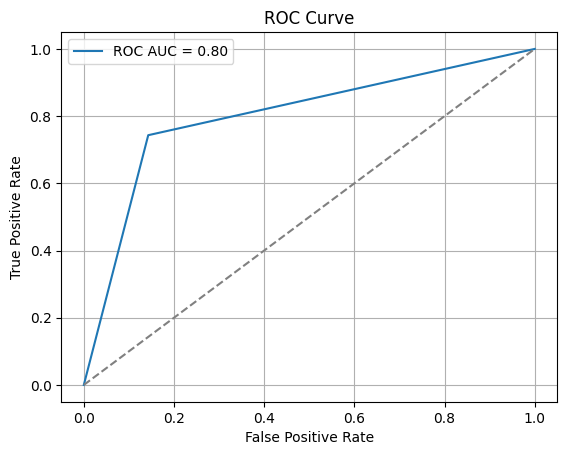

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc = roc_auc_score(y_val, y_pred)

# Graficar curva ROC
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Línea de referencia
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

La imagen representa la **curva ROC** (Característica Operativa del Receptor) para un modelo de clasificación binaria. Aquí está su interpretación:

1. **Tasa de Verdaderos Positivos (TPR)** (eje vertical):
   - También conocida como **sensibilidad** o **recall**, mide la proporción de positivos reales que el modelo clasifica correctamente.
   - Fórmula: $\text{TPR} = \frac{\text{Verdaderos Positivos}}{\text{Verdaderos Positivos} + \text{Falsos Negativos}}$.

2. **Tasa de Falsos Positivos (FPR)** (eje horizontal):
   - Mide la proporción de negativos reales que el modelo clasifica incorrectamente como positivos.
   - Fórmula: $\text{FPR} = \frac{\text{Falsos Positivos}}{\text{Falsos Positivos} + \text{Verdaderos Negativos}}$.

3. **Línea diagonal**:
   - La línea punteada representa un clasificador aleatorio, donde la TPR es igual a la FPR para todos los umbrales (como lanzar una moneda).
   - Un buen modelo tendrá su curva ROC por encima de esta línea.

4. **Curva ROC**:
   - La curva azul muestra el desempeño del modelo en distintos umbrales de decisión.
   - Una curva más pronunciada (más cercana a la esquina superior izquierda) indica un mejor modelo porque logra una alta TPR con una baja FPR.

5. **AUC (Área Bajo la Curva)**:
   - El valor (0.80) cuantifica la capacidad general del modelo para distinguir entre las clases positivas y negativas.
   - Un AUC de 0.80 significa que el modelo tiene un 80% de probabilidad de clasificar correctamente una instancia positiva al compararla con una instancia negativa al azar.

En este caso, el modelo tiene un buen desempeño, aunque no es perfecto (un AUC de 1.0 representaría un clasificador perfecto).

| **Métrica**      | **Definición**                                                                                         | **Ventajas**                                                                                       | **Desventajas**                                                                                   | **Usos Principales**                                                                                                                                   |
|-------------------|-----------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------|
| **ROC AUC**       | Área bajo la curva ROC, mide la capacidad del modelo para discriminar entre clases.                 | - Independiente del umbral.<br>- Considera tanto positivos como negativos.<br>- Fácil para comparar modelos. | - Difícil de interpretar operativamente.<br>- Menos útil con clases altamente desbalanceadas.     | Evaluar el desempeño general de un modelo.<br>Comparar clasificadores en problemas de clases desbalanceadas.                                           |
| **Precisión**     | Proporción de predicciones positivas correctas.                                                     | - Útil cuando los **falsos positivos** son costosos.<br>- Se enfoca en la calidad de las predicciones positivas. | - Ignora los falsos negativos.<br>- No es útil si el interés está en capturar todos los positivos. | Aplicaciones como detección de fraude, donde los falsos positivos tienen un alto costo.                                                                |
| **Recall**        | Proporción de positivos reales identificados correctamente.                                         | - Es crucial cuando los **falsos negativos** son críticos.<br>- Complementa a la precisión.       | - Ignora los falsos positivos.<br>- Puede llevar a un exceso de positivos predichos con baja precisión. | Detección de enfermedades o problemas donde no detectar un positivo tiene graves consecuencias (ejemplo: diagnóstico médico).                          |
| **F1-Score**      | Media armónica entre precisión y recall.                                                            | - Balancea precisión y recall.<br>- Útil en problemas desbalanceados.                            | - No considera los negativos correctamente clasificados.<br>- Difícil interpretación en casos prácticos. | Problemas desbalanceados donde se necesita equilibrar precisión y recall, como detección de spam o clasificación de texto.                             |




### 4. Optimización:

**a. Ajuste de hiperparámetros:**
El ajuste de hiperparámetros puede mejorar significativamente el rendimiento de un modelo. Una técnica común es la búsqueda en cuadrícula.

In [21]:
from sklearn.model_selection import GridSearchCV

# Definir los hiperparámetros y sus posibles valores
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Inicializar la búsqueda en cuadrícula
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')

# Ajustar el modelo con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Ver los mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

Mejores hiperparámetros: {'C': 0.1}


In [22]:

# Evaluar el modelo con los mejores hiperparámetros en el conjunto de validación
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy con los mejores hiperparámetros: {accuracy:.4f}")

Accuracy con los mejores hiperparámetros: 0.7989



**b. Probar diferentes modelos:**
No te limites a un solo modelo. Es posible que otros modelos, como los árboles de decisión, bosques aleatorios o máquinas de soporte vectorial, funcionen mejor para tu conjunto de datos.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar un modelo de bosque aleatorio
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluar el rendimiento
y_pred = rf_model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy del bosque aleatorio: {accuracy:.4f}")

Accuracy del bosque aleatorio: 0.8212


In [24]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179




**c. Ensamblar modelos:**
A veces, combinar las predicciones de varios modelos (ensamblaje) puede mejorar el rendimiento general.

```python
# Hacer predicciones con ambos modelos
y_pred_logistic = best_model.predict(X_val)
y_pred_rf = rf_model.predict(X_val)

# Combinar las predicciones (votación mayoritaria)
y_pred_ensemble = (y_pred_logistic + y_pred_rf) > 1

accuracy = accuracy_score(y_val, y_pred_ensemble)
print(f"Accuracy del ensamblaje: {accuracy:.4f}")
```

In [25]:
# Hacer predicciones con ambos modelos
y_pred_logistic = best_model.predict(X_val)
y_pred_rf = rf_model.predict(X_val)

# Combinar las predicciones (votación mayoritaria)
y_pred_ensemble = (y_pred_logistic + y_pred_rf) > 1

accuracy = accuracy_score(y_val, y_pred_ensemble)
print(f"Accuracy del ensamblaje: {accuracy:.4f}")

Accuracy del ensamblaje: 0.8101



Estos pasos te ayudarán a optimizar tu modelo y potencialmente mejorar su rendimiento. Una vez que estés satisfecho con el rendimiento del modelo, puedes entrenarlo con todo el conjunto de entrenamiento y hacer predicciones en el conjunto de prueba.


## XGBoost

In [26]:
import xgboost as xgb

# Entrenar un modelo de bosque aleatorio
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
accuracy


0.8044692737430168

In [27]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



Avancemos con la **Evaluación Final** y la preparación del archivo de envío para Kaggle.

### 5. Evaluación Final:

**a. Entrenar el modelo final:**
Una vez que hayas seleccionado y optimizado tu modelo, es hora de entrenarlo con todo el conjunto de entrenamiento para aprovechar al máximo los datos disponibles.

```python
# Usando el modelo de bosque aleatorio como ejemplo
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)
```

In [28]:
# Usando el modelo de bosque aleatorio como ejemplo
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)

RandomForestClassifier(random_state=42)


**b. Predecir las etiquetas para el conjunto de datos de prueba:**
Antes de hacer predicciones, asegúrate de que el conjunto de datos de prueba haya pasado por el mismo preprocesamiento que el conjunto de entrenamiento.

```python
# Preprocesar el conjunto de datos de prueba (asegúrate de aplicar las mismas transformaciones)
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)
test_data['Sex'] = test_data['Sex'].map({'female': 0, 'male': 1}).astype(int)
test_data[['Age', 'Fare']] = scaler.transform(test_data[['Age', 'Fare']])

# Hacer predicciones
test_predictions = final_model.predict(test_data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1))
```

In [29]:
# Preprocesar el conjunto de datos de prueba
passenger_ids = test_data['PassengerId']
test_data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
# Rellenar valores faltantes
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)

# Convertir género a formato numérico
test_data['Sex'] = test_data['Sex'].map({'female': 0, 'male': 1}).astype(int)

# Codificación One-Hot para 'Embarked'
embarked_dummies_test = pd.get_dummies(test_data['Embarked'], prefix='Embarked')
test_data = pd.concat([test_data, embarked_dummies_test], axis=1)
test_data.drop('Embarked', axis=1, inplace=True)

# Crear la característica 'FamilySize'
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1

# Escalar características
test_data[['Age', 'Fare']] = scaler.transform(test_data[['Age', 'Fare']])

/tmp/ipykernel_18/2243211537.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Age'].fillna(test_data['Age'].median(), inplace=True)


In [30]:
test_data.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          1
Embarked_C    0
Embarked_Q    0
Embarked_S    0
FamilySize    0
dtype: int64

In [31]:
test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)
test_data['Fare'].isnull().sum()

/tmp/ipykernel_18/1370080081.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)


0

In [32]:

# Hacer predicciones
test_predictions = final_model.predict(test_data)



**c. Preparar un archivo de envío para Kaggle:**
Kaggle generalmente requiere que envíes tus predicciones en un formato específico. Para la competencia del Titanic, necesitas un archivo CSV con dos columnas: `PassengerId` y `Survived`.

```python
# Crear un DataFrame para el envío
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': test_predictions
})

# Guardar el DataFrame como un archivo CSV
submission.to_csv('submission.csv', index=False)
```

In [33]:
# Crear un DataFrame para el envío
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


In [34]:
# Guardar el DataFrame como un archivo CSV
submission.to_csv('submission.csv', index=False)


¡Listo! Ahora tienes un archivo `submission.csv` que puedes enviar a Kaggle y ver cómo se desempeña tu modelo en el conjunto de datos de prueba.

Es importante recordar que la competencia del Titanic en Kaggle es una excelente oportunidad para aprender y experimentar. No te desanimes si tu modelo no se encuentra en la parte superior de la tabla de clasificación. Lo más importante es el proceso de aprendizaje y la experiencia adquirida.
